# 03a — CNN from Scratch · Alertreck Threat Detection

**Model:** 4-block CNN trained on 128-bin log-mel spectrograms  
**Classes:** 7 fine-grained (background_animals, background_wind_rain, threat_chainsaw, threat_dog, threat_gunshot, threat_human, threat_vehicle)  
**Data:** `data/processed/mel/` shards from Stage 2 preprocessing  
**Platform:** Local (alertreck conda env) — or Kaggle with GPU

---

## Local Setup

Run from the repo root with the alertreck conda env:
```bash
conda activate alertreck
conda install -n alertreck -c conda-forge pytorch torchvision seaborn -y
jupyter notebook notebooks/03a-train-cnn.ipynb
```

In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import seaborn as sns

print(f'PyTorch  {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   {device}')
if device.type == 'cuda':
    print(f'GPU      {torch.cuda.get_device_name(0)}')
    print(f'VRAM     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch  2.10.0+cu128
Device   cuda
GPU      Tesla T4
VRAM     15.6 GB


In [2]:
# ── 2. Config ─────────────────────────────────────────────────────────────────
CFG = {
    # paths — relative to notebooks/ directory
    'data_root':   Path('/kaggle/input/datasets/orpheusmanga/alertreck-mel2/mel'),
    'output_dir':  Path('/kaggle/working/models/custom_cnn'),

    # model
    'n_classes':   7,
    'in_channels': 1,

    # spectrogram shape from Stage 2 (SR=44100, clip=3s, hop_stft=441, center=True)
    # actual shard shape verified: (128, 301)
    'n_mels':      128,
    'n_frames':    301,

    # training
    'seed':        42,
    'epochs':      60,
    'batch_size':  256,
    'lr':          1e-3,
    'weight_decay':1e-4,
    'patience':    10,       # early stopping on val macro-F1

    # focal loss
    'focal_gamma': 2.0,

    # curriculum phase epoch budgets (A → B → C)
    # Phase A: clean + SNR≥15dB augmented clips
    # Phase B: clean + 10–15dB augmented clips
    # Phase C: clean + 5–10dB augmented clips (hardest)
    'phase_epochs': {'A': 20, 'B': 15, 'C': 999},

    # labels (must match label_map in manifest.json)
    'label_names': [
        'background_animals',
        'background_wind_rain',
        'threat_chainsaw',
        'threat_dog',
        'threat_gunshot',
        'threat_human',
        'threat_vehicle',
    ],
}

CFG['output_dir'].mkdir(parents=True, exist_ok=True)

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
if device.type == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])

print('Config OK')
print(f"Data root : {CFG['data_root'].resolve()}")
print(f"Output    : {CFG['output_dir'].resolve()}")
print(f"Mel shape : ({CFG['n_mels']}, {CFG['n_frames']})")


Config OK
Data root : /kaggle/input/datasets/orpheusmanga/alertreck-mel2/mel
Output    : /kaggle/working/models/custom_cnn
Mel shape : (128, 301)


In [3]:
# ── 3. Dataset ────────────────────────────────────────────────────────────────
class ShardDataset(Dataset):
    """
    Loads all .npz shards from a split directory into memory.
    Each shard contains X (N, 128, 300) float32 and y (N,) int8.
    """
    def __init__(self, shard_dir: Path, augment: bool = False):
        shards = sorted(shard_dir.glob('*.npz'))
        assert shards, f'No shards found in {shard_dir}'

        xs, ys = [], []
        for s in tqdm(shards, desc=f'Loading {shard_dir.name}'):
            d = np.load(s)
            xs.append(d['X'])
            ys.append(d['y'].astype(np.int64))

        self.X = np.concatenate(xs, axis=0)   # (N, 128, 300)
        self.y = np.concatenate(ys, axis=0)   # (N,)
        self.augment = augment
        print(f'  {shard_dir.name}: {len(self.X):,} samples')

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        mean_val = x.mean()

        if self.augment:
            # SpecAugment — 2 freq masks (max 20 bins) + 2 time masks (max 40 frames)
            for _ in range(2):
                f_width = random.randint(0, 20)
                f0 = random.randint(0, x.shape[0] - f_width)
                x[f0:f0 + f_width, :] = mean_val
            for _ in range(2):
                t_width = random.randint(0, 40)
                t0 = random.randint(0, x.shape[1] - t_width)
                x[:, t0:t0 + t_width] = mean_val

        # add channel dim → (1, 128, 300)
        x = torch.from_numpy(x).unsqueeze(0)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


data_root = CFG['data_root']

# ── load all splits ───────────────────────────────────────────────────────────
print('\nLoading clean splits …')
train_clean_ds = ShardDataset(data_root / 'train',       augment=True)
val_ds         = ShardDataset(data_root / 'val',         augment=False)
test_ds        = ShardDataset(data_root / 'test',        augment=False)

print('\nLoading curriculum augmentation phases …')
train_aug_A_ds = ShardDataset(data_root / 'train_aug_A', augment=True)
train_aug_B_ds = ShardDataset(data_root / 'train_aug_B', augment=True)
train_aug_C_ds = ShardDataset(data_root / 'train_aug_C', augment=True)

# ── curriculum: each phase concatenates clean + augmented shards ─────────────
from torch.utils.data import ConcatDataset

phase_datasets = {
    'A': ConcatDataset([train_clean_ds, train_aug_A_ds]),
    'B': ConcatDataset([train_clean_ds, train_aug_B_ds]),
    'C': ConcatDataset([train_clean_ds, train_aug_C_ds]),
}

def make_train_loader(phase: str) -> DataLoader:
    return DataLoader(phase_datasets[phase], batch_size=CFG['batch_size'],
                      shuffle=True, num_workers=4, pin_memory=True)

val_loader  = DataLoader(val_ds,  batch_size=CFG['batch_size'],
                         shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'],
                         shuffle=False, num_workers=4, pin_memory=True)

print(f'\nVal batches: {len(val_loader)}')
print(f'Phase A train size: {len(phase_datasets["A"]):,}')
print(f'Phase B train size: {len(phase_datasets["B"]):,}')
print(f'Phase C train size: {len(phase_datasets["C"]):,}')


Loading clean splits …


Loading train:   0%|          | 0/11 [00:00<?, ?it/s]

  train: 10,223 samples


Loading val:   0%|          | 0/4 [00:00<?, ?it/s]

  val: 3,392 samples


...

  train_aug_A: 10,223 samples


Loading train_aug_B:   0%|          | 0/21 [00:00<?, ?it/s]

  train_aug_B: 20,446 samples


Loading train_aug_C:   0%|          | 0/31 [00:00<?, ?it/s]

  train_aug_C: 30,669 samples

Val batches: 14
Phase A train size: 20,446
Phase B train size: 30,669
Phase C train size: 40,892


In [4]:
# ── 4. Class weights (handle imbalance) ───────────────────────────────────────
# Use train_clean_ds for class weight computation (clean labels only)
counts = np.bincount(train_clean_ds.y, minlength=CFG['n_classes']).astype(np.float32)
weights = counts.sum() / (CFG['n_classes'] * counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights:')
for i, (name, w) in enumerate(zip(CFG['label_names'], weights)):
    print(f'  [{i}] {name:<26}  n={int(counts[i]):>6}  weight={w:.3f}')

Class weights:
  [0] background_animals          n=  3438  weight=0.425
  [1] background_wind_rain        n=   816  weight=1.790
  [2] threat_chainsaw             n=  1518  weight=0.962
  [3] threat_dog                  n=   650  weight=2.247
  [4] threat_gunshot              n=  1440  weight=1.014
  [5] threat_human                n=  1715  weight=0.852
  [6] threat_vehicle              n=   646  weight=2.261


In [5]:
# ── 5. CNN Architecture ───────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class AudioCNN(nn.Module):
    """
    4-block CNN for mel spectrogram classification.
    Input:  (B, 1, 128, 300)
    Output: (B, n_classes)

    AdaptiveAvgPool2d((1,1)) makes the classifier input-shape agnostic.
    Encoder output → (B, 256, H, W) → pool → (B, 256).
    """
    def __init__(self, n_classes: int):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1,   32,  dropout=0.2),
            ConvBlock(32,  64,  dropout=0.2),
            ConvBlock(64,  128, dropout=0.2),
            ConvBlock(128, 256, dropout=0.2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.pool(x)
        return self.classifier(x)

    def encode(self, x):
        """Return 256-dim embedding (used by ProtoNet Stage 3c)."""
        return self.pool(self.encoder(x)).flatten(1)


model = AudioCNN(n_classes=CFG['n_classes']).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')

# sanity-check with correct shape (128, 300)
dummy = torch.randn(2, 1, CFG['n_mels'], CFG['n_frames']).to(device)
out   = model(dummy)
emb   = model.encode(dummy)
print(f'Forward pass OK : input {tuple(dummy.shape)} → logits {tuple(out.shape)}')
print(f'Encoder embed   : {tuple(emb.shape)}')

Parameters: 1,206,439
Forward pass OK : input (2, 1, 128, 301) → logits (2, 7)
Encoder embed   : (2, 256)


In [6]:
# ── 6. Loss, optimiser, scheduler ─────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal loss with per-class alpha weighting.
    gamma=2 down-weights well-classified examples so the model
    focuses on the rare / hard classes (threat_dog, threat_vehicle).
    """
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha          # (n_classes,) class weights
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        alpha_t = self.alpha[targets]
        loss = alpha_t * (1 - pt) ** self.gamma * ce
        return loss.mean()


criterion = FocalLoss(alpha=class_weights, gamma=CFG['focal_gamma'])

optimizer = optim.AdamW(model.parameters(),
                        lr=CFG['lr'], weight_decay=CFG['weight_decay'])

# CosineAnnealingLR decays smoothly over all epochs — better than
# ReduceLROnPlateau which can stall a curriculum phase mid-run
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-6,
)


In [8]:
# ── 7. Training utilities ─────────────────────────────────────────────────────
def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            preds = logits.argmax(1)
            total_loss += loss.item() * len(y)
            correct    += (preds == y).sum().item()
            n          += len(y)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    epoch_f1 = f1_score(
        torch.cat(all_labels).numpy(),
        torch.cat(all_preds).numpy(),
        average='macro', zero_division=0,
    )
    return total_loss / n, correct / n, epoch_f1


def predict_all(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            preds = model(X.to(device)).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(y)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()


In [9]:
# ── 8. Training loop (curriculum A → B → C) ───────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_f1':   [], 'val_f1':   [],
    'phase': [], 'lr': [],
}
best_val_f1      = 0.0
patience_counter = 0
best_model_path  = CFG['output_dir'] / 'best_model.pt'

def get_phase(epoch: int) -> str:
    if epoch <= CFG['phase_epochs']['A']:
        return 'A'
    elif epoch <= CFG['phase_epochs']['A'] + CFG['phase_epochs']['B']:
        return 'B'
    return 'C'

current_phase = None
train_loader  = None

print(f"Training for up to {CFG['epochs']} epochs")
print(f"Curriculum  : A({CFG['phase_epochs']['A']}ep) → B({CFG['phase_epochs']['B']}ep) → C(rest)")
print(f"Early stop  : patience={CFG['patience']} on val macro-F1\n")
t0 = time.time()

for epoch in range(1, CFG['epochs'] + 1):
    phase = get_phase(epoch)

    if phase != current_phase:
        current_phase = phase
        train_loader  = make_train_loader(phase)
        print(f'  ── Phase {phase} (epoch {epoch}, '
              f'{len(phase_datasets[phase]):,} samples/epoch) ──')

    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, training=True)
    va_loss, va_acc, va_f1 = run_epoch(val_loader,   training=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(va_f1)
    history['phase'].append(phase)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    elapsed = (time.time() - t0) / 60
    print(f'[{phase}] Epoch {epoch:02d}/{CFG["epochs"]}  '
          f'loss={tr_loss:.4f}/{va_loss:.4f}  '
          f'acc={tr_acc:.4f}/{va_acc:.4f}  '
          f'F1={tr_f1:.4f}/{va_f1:.4f}  '
          f'lr={optimizer.param_groups[0]["lr"]:.2e}  '
          f'[{elapsed:.1f} min]')

    if va_f1 > best_val_f1:
        best_val_f1      = va_f1
        patience_counter = 0
        torch.save({
            'epoch':       epoch,
            'phase':       phase,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss':    va_loss,
            'val_acc':     va_acc,
            'val_f1':      va_f1,
            'cfg':         {k: str(v) for k, v in CFG.items()},
        }, best_model_path)
        print(f'  ✓ best model saved (val_F1={va_f1:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print(f'\nEarly stopping at epoch {epoch} '
                  f'(no F1 improvement for {CFG["patience"]} epochs)')
            break

print(f'\nTraining complete in {(time.time()-t0)/60:.1f} min')
print(f'Best val macro-F1: {best_val_f1:.4f}')


Training for up to 60 epochs
Curriculum  : A(20ep) → B(15ep) → C(rest)
Early stop  : patience=10 on val macro-F1

  ── Phase A (epoch 1, 20,446 samples/epoch) ──
[A] Epoch 01/60  loss=0.9697/0.6921  acc=0.4019/0.5495  F1=0.3779/0.5449  lr=9.99e-04  [1.9 min]
  ✓ best model saved (val_F1=0.5449)
[A] Epoch 02/60  loss=0.6888/0.5035  acc=0.5491/0.6070  F1=0.5191/0.6051  lr=9.97e-04  [3.7 min]
  ✓ best model saved (val_F1=0.6051)
[A] Epoch 03/60  loss=0.5499/0.3525  acc=0.6282/0.7521  F1=0.6004/0.7397  lr=9.94e-04  [5.5 min]
  ✓ best model saved (val_F1=0.7397)
[A] Epoch 04/60  loss=0.4637/0.3223  acc=0.6743/0.7252  F1=0.6469/0.7179  lr=9.89e-04  [7.3 min]
[A] Epoch 05/60  loss=0.4121/0.2815  acc=0.7090/0.7795  F1=0.6833/0.7675  lr=9.83e-04  [9.0 min]
  ✓ best model saved (val_F1=0.7675)
[A] Epoch 06/60  loss=0.3808/0.2508  acc=0.7339/0.8016  F1=0.7086/0.7885  lr=9.76e-04  [10.8 min]
  ✓ best model saved (val_F1=0.7885)
[A] Epoch 07/60  loss=0.3448/0.2286  acc=0.7493/0.8264  F1=0.7246/0.81

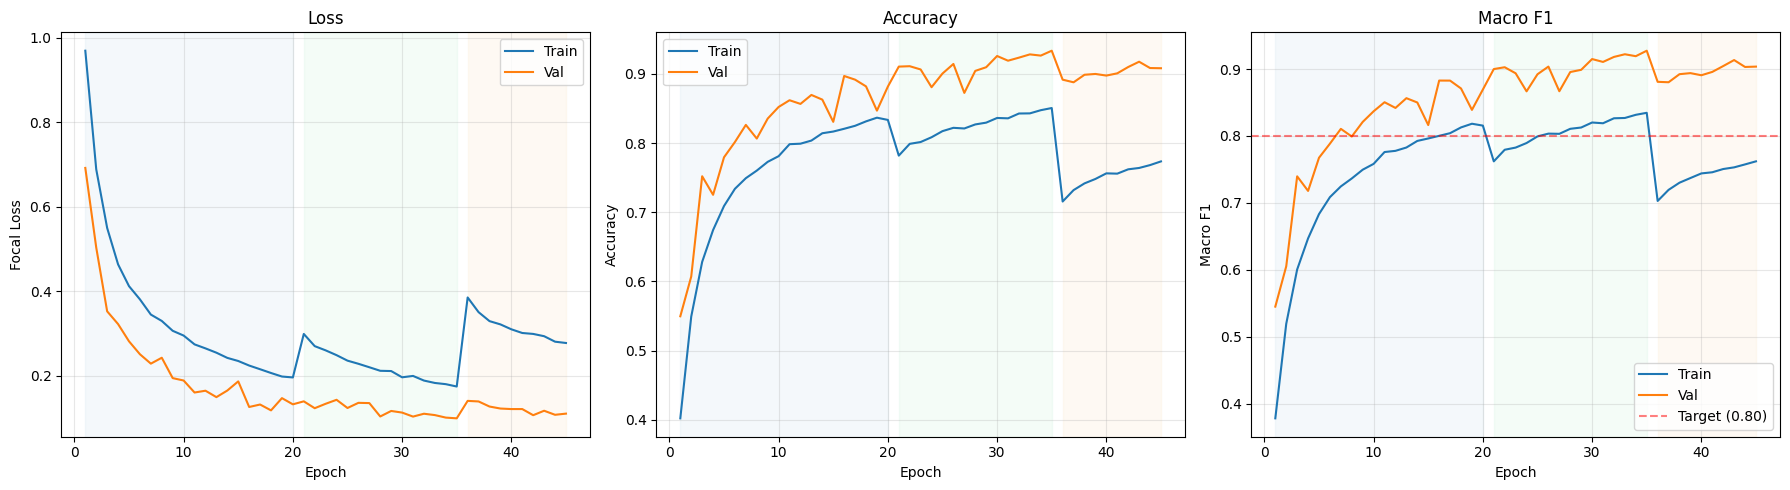

In [10]:
# ── 9. Training curves ────────────────────────────────────────────────────────
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_ran, history['train_loss'], label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history['train_acc'], label='Train')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history['train_f1'], label='Train')
axes[2].plot(epochs_ran, history['val_f1'],   label='Val')
axes[2].axhline(0.80, color='red', linestyle='--', alpha=0.5, label='Target (0.80)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Macro F1')
axes[2].set_title('Macro F1'); axes[2].legend(); axes[2].grid(alpha=0.3)

# shade curriculum phases
phase_list = history['phase']
for ax in axes:
    for i, (p, color) in enumerate([('A','#d4e6f1'), ('B','#d5f5e3'), ('C','#fdebd0')]):
        start = next((e+1 for e, ph in enumerate(phase_list) if ph == p), None)
        end   = max((e+1 for e, ph in enumerate(phase_list) if ph == p), default=None)
        if start and end:
            ax.axvspan(start, end, alpha=0.25, color=color, label=f'Phase {p}')

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'training_curves.png', dpi=150)
plt.show()


In [11]:
# ── 10. Load best model & evaluate on test set ────────────────────────────────
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_F1={checkpoint['val_f1']:.4f}, val_loss={checkpoint['val_loss']:.4f})")

test_preds, test_labels = predict_all(test_loader)

test_acc = (test_preds == test_labels).mean()
test_f1  = f1_score(test_labels, test_preds, average='macro')
print(f'\nTest accuracy : {test_acc:.4f}')
print(f'Test macro-F1 : {test_f1:.4f}')


Loaded best model from epoch 35 (val_F1=0.9275, val_loss=0.0991)

Test accuracy : 0.9264
Test macro-F1 : 0.9166


In [12]:
# ── 11. Per-class classification report ───────────────────────────────────────
print(classification_report(test_labels, test_preds,
                             target_names=CFG['label_names'], digits=4))

                      precision    recall  f1-score   support

  background_animals     0.9460    0.8840    0.9140      1190
background_wind_rain     0.9137    0.9338    0.9236       272
     threat_chainsaw     0.9451    0.9064    0.9254       513
          threat_dog     0.7768    0.8458    0.8098       214
      threat_gunshot     0.9979    1.0000    0.9990       480
        threat_human     0.9147    0.9927    0.9521       551
      threat_vehicle     0.8449    0.9452    0.8922       219

            accuracy                         0.9264      3439
           macro avg     0.9056    0.9297    0.9166      3439
        weighted avg     0.9286    0.9264    0.9266      3439



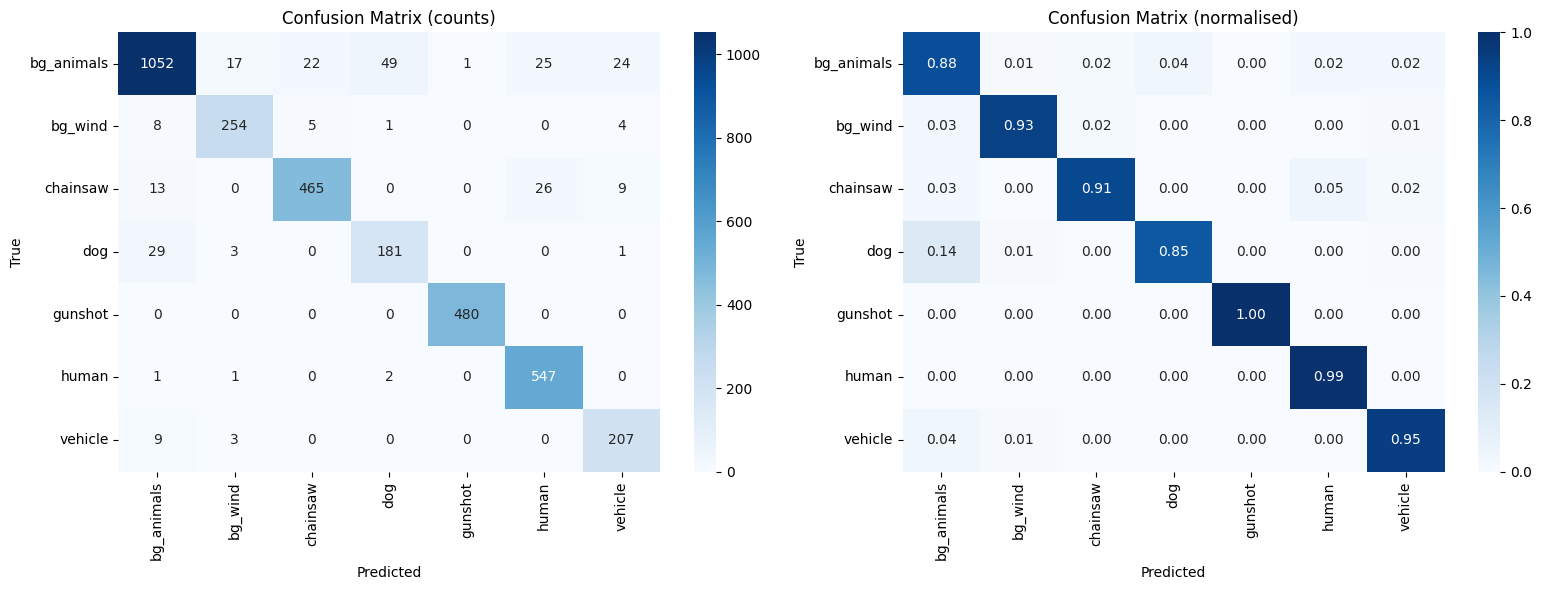

In [13]:
# ── 12. Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

short_names = ['bg_animals', 'bg_wind', 'chainsaw', 'dog', 'gunshot', 'human', 'vehicle']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=short_names, yticklabels=short_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'confusion_matrix.png', dpi=150)
plt.show()

In [14]:
# ── 13. Save results JSON ─────────────────────────────────────────────────────
results = {
    'model':        'CNN from scratch',
    'best_epoch':   int(checkpoint['epoch']),
    'val_loss':     float(checkpoint['val_loss']),
    'val_acc':      float(checkpoint['val_acc']),
    'test_acc':     float(test_acc),
    'test_macro_f1': float(test_f1),
    'per_class_f1': {
        name: float(f1_score(test_labels == i, test_preds == i, average='binary'))
        for i, name in enumerate(CFG['label_names'])
    },
    'n_params':     n_params,
    'history':      history,
}

results_path = CFG['output_dir'] / 'results.json'
results_path.write_text(json.dumps(results, indent=2))
print(f'Results saved → {results_path}')

print('\n=== Summary ===')
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test macro-F1 : {test_f1:.4f}")
print(f"Parameters    : {n_params:,}")
print(f"Best epoch    : {checkpoint['epoch']}")

Results saved → /kaggle/working/models/custom_cnn/results.json

=== Summary ===
Test accuracy : 0.9264
Test macro-F1 : 0.9166
Parameters    : 1,206,439
Best epoch    : 35


In [ ]:
# ── 14. AUC-ROC + Precision-Recall evaluation ────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score,
)
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

# ── collect softmax probabilities on the test set ────────────────────────────
model.eval()
all_probs, all_labels_list = [], []
with torch.no_grad():
    for X, y in test_loader:
        logits = model(X.to(device))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels_list.append(y.numpy())

probs_all  = np.concatenate(all_probs,       axis=0)   # (N, 7)
labels_all = np.concatenate(all_labels_list, axis=0)   # (N,)

# one-hot encode labels for sklearn multi-class ROC
labels_bin = label_binarize(labels_all, classes=list(range(CFG['n_classes'])))

# ── per-class AUC-ROC ─────────────────────────────────────────────────────────
auc_scores = {}
for i, name in enumerate(CFG['label_names']):
    auc_scores[name] = roc_auc_score(labels_bin[:, i], probs_all[:, i])

macro_auc = roc_auc_score(labels_bin, probs_all, average='macro')

print("=== AUC-ROC (target > 0.85) ===")
for name, auc in auc_scores.items():
    flag = '✓' if auc >= 0.85 else '✗ BELOW TARGET'
    print(f"  {name:<26}  AUC={auc:.4f}  {flag}")
print(f"  {'macro average':<26}  AUC={macro_auc:.4f}")

# ── per-class precision / recall ─────────────────────────────────────────────
preds_all = probs_all.argmax(axis=1)
print("\n=== Precision / Recall / F1 per class ===")
print(f"  {'Class':<26}  {'Prec':>6}  {'Rec':>6}  {'F1':>6}  {'AP':>6}")
print("  " + "-" * 56)
ap_scores = {}
for i, name in enumerate(CFG['label_names']):
    prec  = precision_score(labels_all == i, preds_all == i, zero_division=0)
    rec   = recall_score(labels_all == i, preds_all == i, zero_division=0)
    f1_i  = 2 * prec * rec / (prec + rec + 1e-9)
    ap    = average_precision_score(labels_bin[:, i], probs_all[:, i])
    ap_scores[name] = ap
    print(f"  {name:<26}  {prec:>6.4f}  {rec:>6.4f}  {f1_i:>6.4f}  {ap:>6.4f}")

macro_ap = np.mean(list(ap_scores.values()))
print(f"  {'macro average':<26}  {'':>6}  {'':>6}  {test_f1:>6.4f}  {macro_ap:>6.4f}")

# ── ROC curves ────────────────────────────────────────────────────────────────
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for i, (name, color) in enumerate(zip(CFG['label_names'], colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs_all[:, i])
    ax.plot(fpr, tpr, color=color, lw=1.8,
            label=f'{name.replace("_"," ")} (AUC={auc_scores[name]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.axvline(0.20, color='red', linestyle=':', lw=1.2, alpha=0.6, label='FPR=20% limit')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — macro AUC={macro_auc:.4f}')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

# ── Precision-Recall curves ───────────────────────────────────────────────────
ax = axes[1]
for i, (name, color) in enumerate(zip(CFG['label_names'], colors)):
    prec_c, rec_c, _ = precision_recall_curve(labels_bin[:, i], probs_all[:, i])
    ax.plot(rec_c, prec_c, color=color, lw=1.8,
            label=f'{name.replace("_"," ")} (AP={ap_scores[name]:.3f})')
ax.axhline(0.80, color='red', linestyle=':', lw=1.2, alpha=0.6, label='Precision=0.80')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curves — macro AP={macro_ap:.4f}')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig(CFG['output_dir'] / 'roc_pr_curves.png', dpi=150)
plt.show()

# ── FPR @ operating threshold (argmax) ───────────────────────────────────────
print("\n=== False Positive Rate @ argmax threshold ===")
for i, name in enumerate(CFG['label_names']):
    fp = ((preds_all == i) & (labels_all != i)).sum()
    tn = ((preds_all != i) & (labels_all != i)).sum()
    fpr_op = fp / (fp + tn) if (fp + tn) > 0 else 0
    flag = '✓' if fpr_op < 0.20 else '✗ ABOVE LIMIT'
    print(f"  {name:<26}  FPR={fpr_op:.4f}  {flag}")

# ── append AUC / AP to results.json ──────────────────────────────────────────
results_path = CFG['output_dir'] / 'results.json'
results_data = json.loads(results_path.read_text())
results_data['per_class_auc']    = auc_scores
results_data['per_class_ap']     = ap_scores
results_data['macro_auc']        = float(macro_auc)
results_data['macro_ap']         = float(macro_ap)
results_path.write_text(json.dumps(results_data, indent=2))
print(f"\nAUC/AP metrics appended → {results_path}")


In [15]:
# ── 15. Export to ONNX (for Pi deployment via ONNX Runtime) ───────────────────
import torch.onnx

onnx_path = CFG['output_dir'] / 'alertreck_cnn.onnx'

model.eval()
# dummy shape must match actual shard shape: (1, 128, 301)
dummy_input = torch.randn(1, 1, CFG['n_mels'], CFG['n_frames']).to(device)

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    dynamo=False,                      # legacy TorchScript exporter — no onnxscript dep
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['mel_spectrogram'],
    output_names=['class_logits'],
    dynamic_axes={
        'mel_spectrogram': {0: 'batch_size'},
        'class_logits':    {0: 'batch_size'},
    },
)
print(f'ONNX model saved → {onnx_path}')
print(f'Input  : (batch, 1, {CFG["n_mels"]}, {CFG["n_frames"]})')
print(f'Output : (batch, {CFG["n_classes"]})')

# save model config alongside for inference script
model_config = {
    'n_classes':   CFG['n_classes'],
    'n_mels':      CFG['n_mels'],
    'n_frames':    CFG['n_frames'],
    'label_names': CFG['label_names'],
    'test_acc':    float(test_acc),
    'test_macro_f1': float(test_f1),
    'best_epoch':  int(checkpoint['epoch']),
    'best_val_f1': float(checkpoint['val_f1']),
    'best_phase':  checkpoint.get('phase', 'unknown'),
}
config_path = CFG['output_dir'] / 'model_config_custom_cnn.json'
config_path.write_text(json.dumps(model_config, indent=2))
print(f'Model config    → {config_path}')


/tmp/ipykernel_58/3130214811.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX model saved → /kaggle/working/models/custom_cnn/alertreck_cnn.onnx
Input  : (batch, 1, 128, 301)
Output : (batch, 7)
Model config    → /kaggle/working/models/custom_cnn/model_config_custom_cnn.json
